<a href="https://colab.research.google.com/github/Lezcanoc2/Free_Practice/blob/main/image-compression-svd-numpy.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os
print(os.listdir())

['.config', 'sample_data', 'Yo.png']


Usando imagen local...
Matriz Original: (1184, 864) (Pixeles)
La IA encontro 864 componentes de informacion en tu cara.


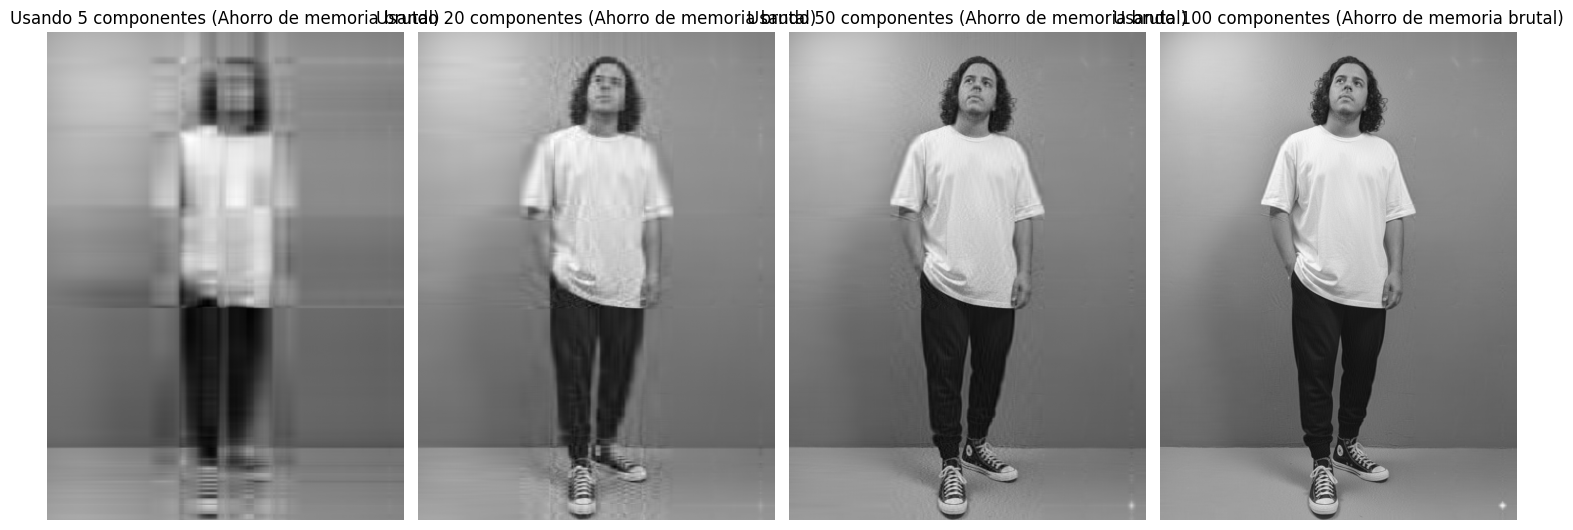

con k=50, he comprimido la imagen teoricamente un 90.0%


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import urllib.request
from PIL import Image

#1. uploading datas
try:
  # loading the local file.
  img = imread('Yo.png')
  print("Usando imagen local...")
except FileNotFoundError:
    print("Local image not found. Usando imagen de ejemplo desde URL...")
    try:
        # If local file not found, will load from URL using PIL
        with urllib.request.urlopen('https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/402px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg') as url_response:
            img = np.array(Image.open(url_response))
    except Exception as e:
        print(f"Error al cargar la imagen desde la URL: {e}")
        # Fallback if URL loading also fails, e.g., create a dummy image or exit
        img = np.zeros((100, 100)) # Create a dummy black image
        print("Creando una imagen de respaldo (matriz de ceros).")

print(f"Matriz Original: {img_gray.shape} (Pixeles)")

U, Sigma, Vt = np.linalg.svd(img_gray, full_matrices=False)

print(f"La IA encontro {len(Sigma)} componentes de informacion en tu cara.")

def reconstruir_imagen(k):
    reconstruccion = U[:, :k] @ np.diag(Sigma[:k]) @ Vt[:k, :]
    return reconstruccion

componentes_a_probar = [5, 20, 50, 100]
plt.figure(figsize=(15,8))

for i, k in enumerate(componentes_a_probar):
    img_comprimida = reconstruir_imagen(k)

    plt.subplot(1, 4, i+1)
    plt.imshow(img_comprimida, cmap='gray')
    plt.title(f"Usando {k} componentes (Ahorro de memoria brutal)")
    plt.axis('off')

plt.tight_layout()
plt.show()

original_size = img_gray.size
comprimido_size = (U.shape[0]*50) + 50 + (Vt.shape[1]*50)
ratio = (1 - (comprimido_size / original_size)) * 100
print(f"con k=50, he comprimido la imagen teoricamente un {ratio:.1f}%")